In [1]:
from collections import defaultdict
import json
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns

In [2]:
def load_data(path):
    data = []
    for root, dirs, files in os.walk(path):
        for filename in files:
            if filename.endswith(".json"):
                file_path = os.path.join(root, filename)
                try:
                    with open(file_path, "r") as f:
                        entry = json.load(f)
                        data.append(entry)
                except json.JSONDecodeError as e:
                    print(f"Skipped invalid JSON: {file_path} ({e})")
                    
    print(f"Loaded {len(data)} valid JSON result files from '{folder_path}' and its subfolders.")
    return data

folder_path = "../results/base/base_cues_5/"
data_cues_5 = load_data(folder_path)
folder_path = "../results/base/base_cues_10/"
data_cues_10 = load_data(folder_path)
folder_path = "../results/base/base_none_5/"
data_none_5 = load_data(folder_path)
folder_path = "../results/base/base_none_10/"
data_none_10 = load_data(folder_path)

data_cues = data_cues_5 + data_cues_10
data_none = data_none_5 + data_none_10
data_5 = data_cues_5 + data_none_5
data_10 = data_cues_10 + data_none_10

Loaded 3772 valid JSON result files from '../results/base/base_cues_5/' and its subfolders.
Loaded 6697 valid JSON result files from '../results/base/base_cues_10/' and its subfolders.
Loaded 4218 valid JSON result files from '../results/base/base_none_5/' and its subfolders.
Loaded 4151 valid JSON result files from '../results/base/base_none_10/' and its subfolders.


In [3]:
model_names = ["claude", "deepseek", "gemini", "gpt", "llama", "mistral", "qwen"]
pretty_names = {
    "gpt": "GPT",
    "llama": "LLaMA",
    "mistral": "Mistral",
    "claude": "Claude",
    "qwen": "Qwen",
    "gemini": "Gemini",
    "deepseek": "DeepSeek"
}

def transform_data_count(data):
    total_counts = {a: {b: 0 for b in model_names} for a in model_names}
    
    for entry in data:
        model_0 = entry["model_general_name_0"].lower()
        model_1 = entry["model_general_name_1"].lower()
        guess_0 = entry["agent_0_guess"].lower()
        guess_1 = entry["agent_1_guess"].lower()
    
        if model_0 in model_names and guess_0 in model_names:
            total_counts[model_0][guess_0] += 1

        if model_1 in model_names and guess_1 in model_names:
            total_counts[model_1][guess_1] += 1
    
    accuracy_matrix = {
        a: {
            b: total_counts[a][b] for b in model_names
        }
        for a in model_names
    }

    normalized_matrix = {
        outer: {
            inner: val / sum(inner_dict.values())
            for inner, val in inner_dict.items()
        }
        for outer, inner_dict in total_counts.items()
    }
    
    df_accuracy = pd.DataFrame(normalized_matrix).T

    return df_accuracy

df_5_c_count = transform_data_count(data_cues_5)
df_10_c_count = transform_data_count(data_cues_10)
df_5_n_count = transform_data_count(data_none_5)
df_10_n_count = transform_data_count(data_none_10)

df_c_count = transform_data_count(data_cues)
df_n_count = transform_data_count(data_none)
df_5_count = transform_data_count(data_5)
df_10_count = transform_data_count(data_10)

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

# Use serif font
matplotlib.rcParams.update({"font.family": "serif"})

def show_plot(df, savename, title, rangify=True, fmt=".2f"):
    # Generate heatmap
    plt.figure(figsize=(14, 12))

    if fmt != "d":
        df = df.astype(float)
        
    if rangify:
        ax = sns.heatmap(
            df,
            annot=True,
            fmt=fmt,
            cmap='YlGnBu',
            linewidths=0.5,
            square=True,
            vmin=0,
            vmax=1,
            annot_kws={"fontsize": 22}
        )
    else:
        if fmt == "d":
            ax = sns.heatmap(
                df,
                annot=True,
                fmt=fmt,
                cmap='YlGnBu',
                linewidths=0.5,
                square=True,
                annot_kws={"fontsize": 22}
            )
        else:
            ax = sns.heatmap(
                df,
                annot=True,
                fmt=fmt,
                cmap='YlGnBu',
                linewidths=0.5,
                square=True,
                vmin=0,
                vmax=1,
                annot_kws={"fontsize": 22}
            )
    
    # Titles and axis labels
    plt.title(title, fontsize=30, pad=30)
    plt.xlabel("Target Model", fontsize=28, labelpad=25)
    plt.ylabel("Guesser Model", fontsize=28, labelpad=25)
    
    # Apply pretty labels to ticks
    x_labels = [pretty_names.get(label.get_text(), label.get_text()) for label in ax.get_xticklabels()]
    y_labels = [pretty_names.get(label.get_text(), label.get_text()) for label in ax.get_yticklabels()]
    
    ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=28)
    ax.set_yticklabels(y_labels, rotation=0, fontsize=28)
    
    # Colorbar font size
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=28)
    
    # Save high-res output
    plt.tight_layout()
    plt.savefig(f"figures_and_files/{savename}.eps", dpi=300, bbox_inches='tight')
    plt.show()

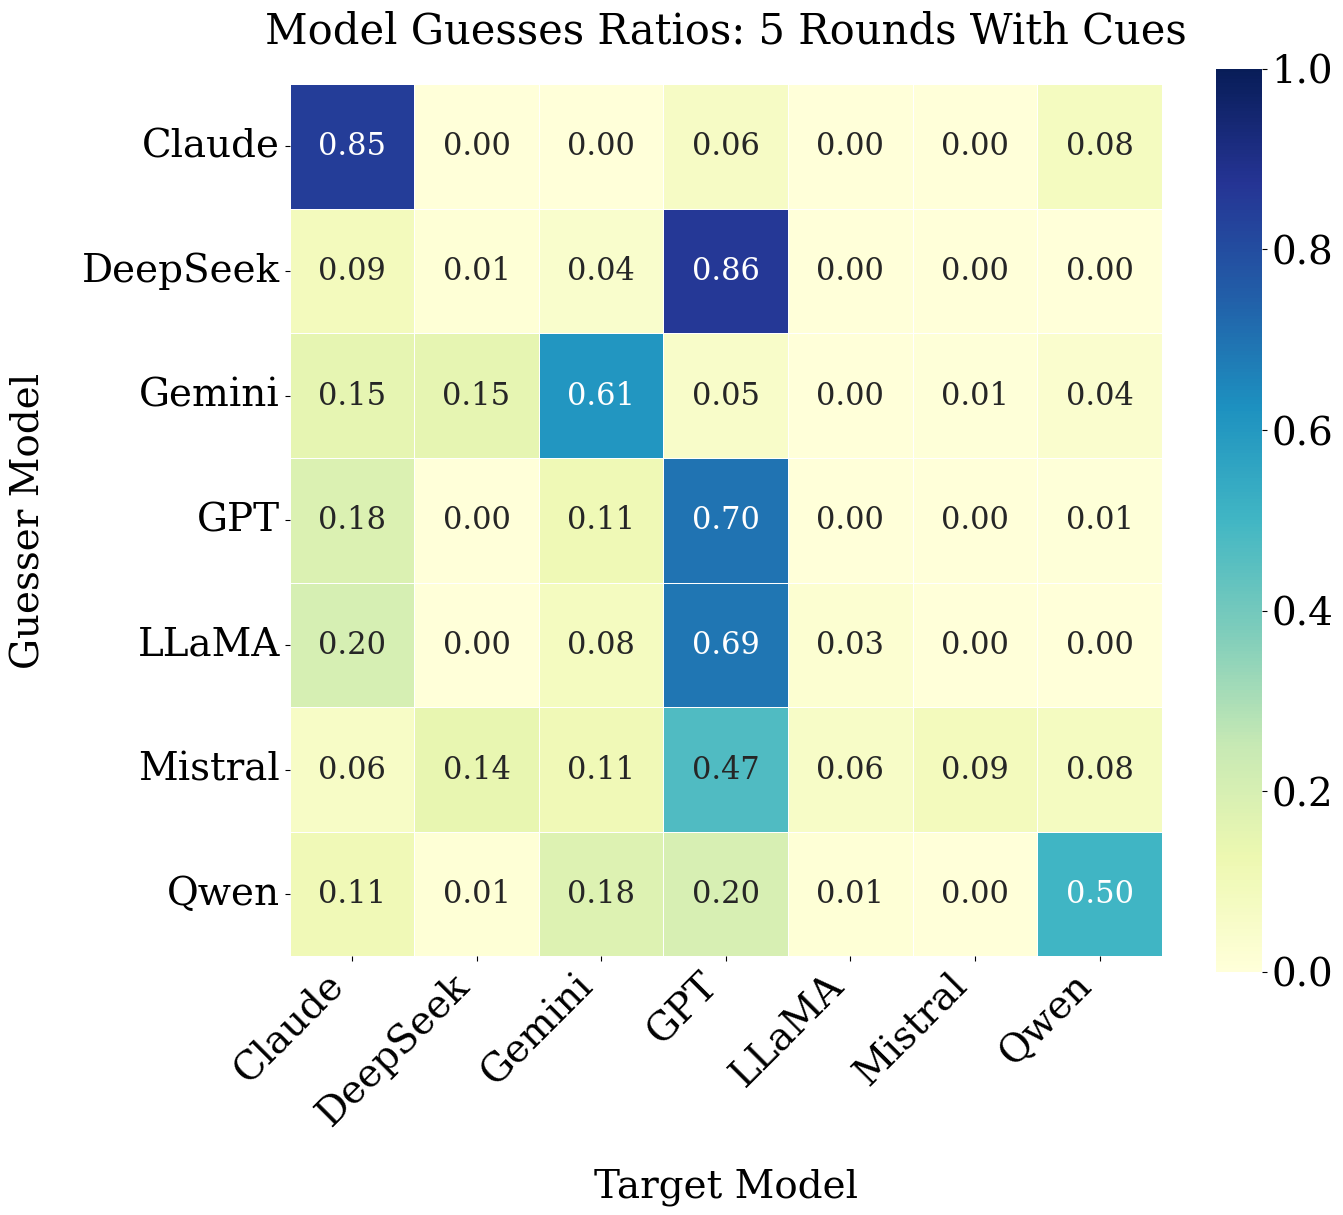

\begin{tabular}{lrrrrrrr}
\toprule
 & claude & deepseek & gemini & gpt & llama & mistral & qwen \\
\midrule
claude & 0.846957 & 0.003478 & 0.001739 & 0.062609 & 0.001739 & 0.001739 & 0.081739 \\
deepseek & 0.087979 & 0.008711 & 0.040941 & 0.859756 & 0.000000 & 0.000871 & 0.001742 \\
gemini & 0.148660 & 0.149525 & 0.605877 & 0.053587 & 0.000000 & 0.006914 & 0.035436 \\
gpt & 0.184367 & 0.000850 & 0.112150 & 0.695837 & 0.001699 & 0.000000 & 0.005098 \\
llama & 0.200172 & 0.000859 & 0.081615 & 0.689003 & 0.026632 & 0.000000 & 0.001718 \\
mistral & 0.059233 & 0.141986 & 0.106272 & 0.471254 & 0.057491 & 0.086237 & 0.077526 \\
qwen & 0.108085 & 0.008511 & 0.176170 & 0.195745 & 0.009362 & 0.000851 & 0.501277 \\
\bottomrule
\end{tabular}



In [5]:
show_plot(df_5_c_count, "count_c5", "Model Guesses Ratios: 5 Rounds With Cues", rangify=False, fmt=".2f")
print(df_5_c_count.to_latex())

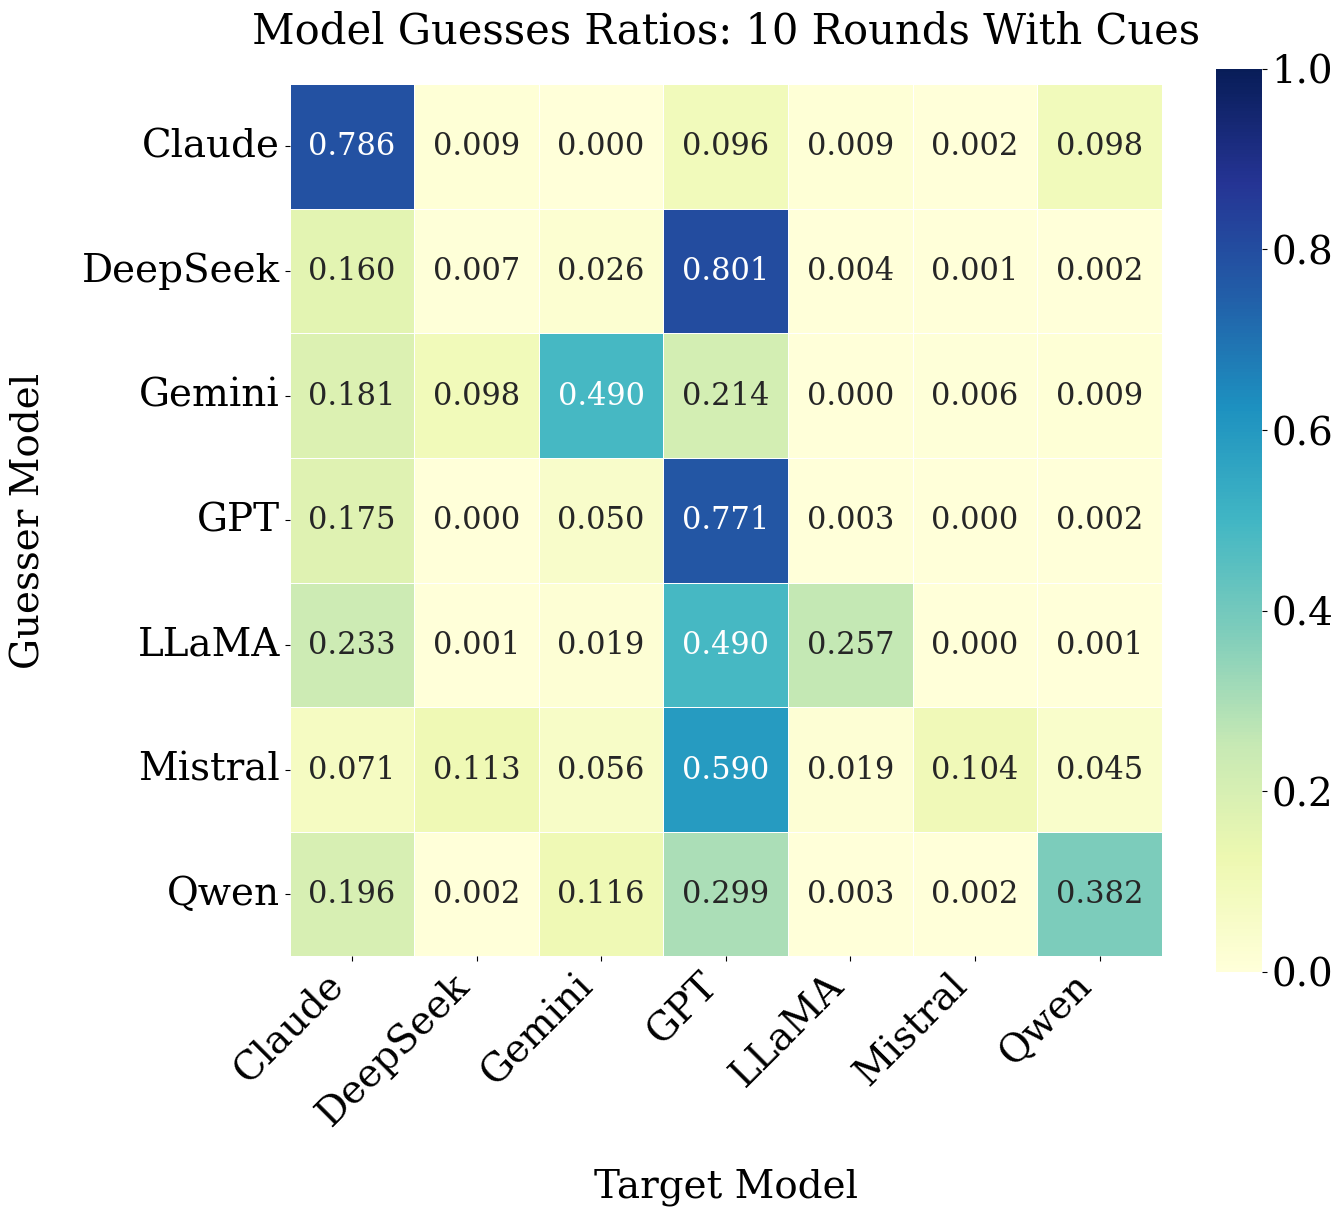

\begin{tabular}{lrrrrrrr}
\toprule
 & claude & deepseek & gemini & gpt & llama & mistral & qwen \\
\midrule
claude & 0.786370 & 0.009174 & 0.000000 & 0.095675 & 0.009174 & 0.001966 & 0.097641 \\
deepseek & 0.159552 & 0.007471 & 0.025614 & 0.801494 & 0.003735 & 0.000534 & 0.001601 \\
gemini & 0.181128 & 0.098151 & 0.490280 & 0.214320 & 0.000474 & 0.006164 & 0.009483 \\
gpt & 0.174545 & 0.000000 & 0.049545 & 0.771364 & 0.002727 & 0.000000 & 0.001818 \\
llama & 0.232558 & 0.000529 & 0.019027 & 0.490486 & 0.256871 & 0.000000 & 0.000529 \\
mistral & 0.071138 & 0.113313 & 0.056402 & 0.590447 & 0.019309 & 0.104167 & 0.045224 \\
qwen & 0.195616 & 0.002192 & 0.115616 & 0.299178 & 0.002740 & 0.002192 & 0.382466 \\
\bottomrule
\end{tabular}



In [6]:
show_plot(df_10_c_count, "count_c10", "Model Guesses Ratios: 10 Rounds With Cues", rangify=False, fmt=".3f")
print(df_10_c_count.to_latex())

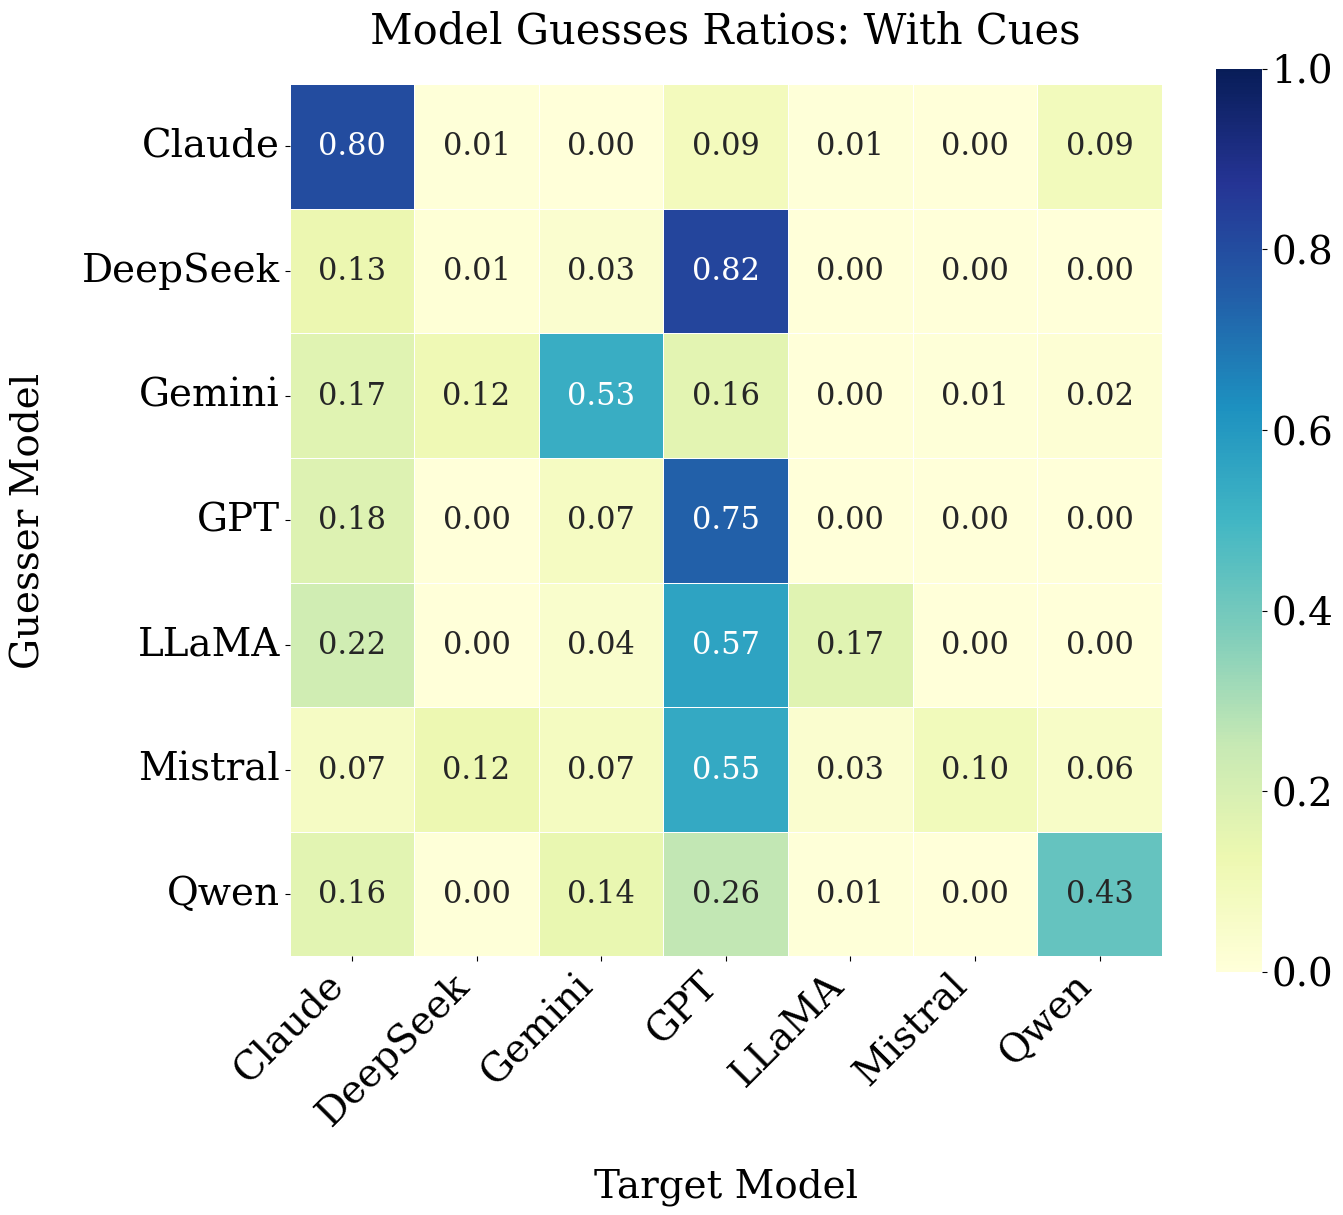

\begin{tabular}{lrrrrrrr}
\toprule
 & claude & deepseek & gemini & gpt & llama & mistral & qwen \\
\midrule
claude & 0.802951 & 0.007615 & 0.000476 & 0.086625 & 0.007139 & 0.001904 & 0.093289 \\
deepseek & 0.132363 & 0.007942 & 0.031436 & 0.823627 & 0.002316 & 0.000662 & 0.001655 \\
gemini & 0.169626 & 0.116350 & 0.531231 & 0.157379 & 0.000306 & 0.006430 & 0.018677 \\
gpt & 0.177969 & 0.000296 & 0.071365 & 0.745040 & 0.002369 & 0.000000 & 0.002961 \\
llama & 0.220223 & 0.000654 & 0.042866 & 0.566099 & 0.169175 & 0.000000 & 0.000982 \\
mistral & 0.066752 & 0.123877 & 0.074775 & 0.546534 & 0.033376 & 0.097561 & 0.057125 \\
qwen & 0.161333 & 0.004667 & 0.139333 & 0.258667 & 0.005333 & 0.001667 & 0.429000 \\
\bottomrule
\end{tabular}



In [7]:
show_plot(df_c_count, "count_c", "Model Guesses Ratios: With Cues", rangify=False, fmt=".2f")
print(df_c_count.to_latex())

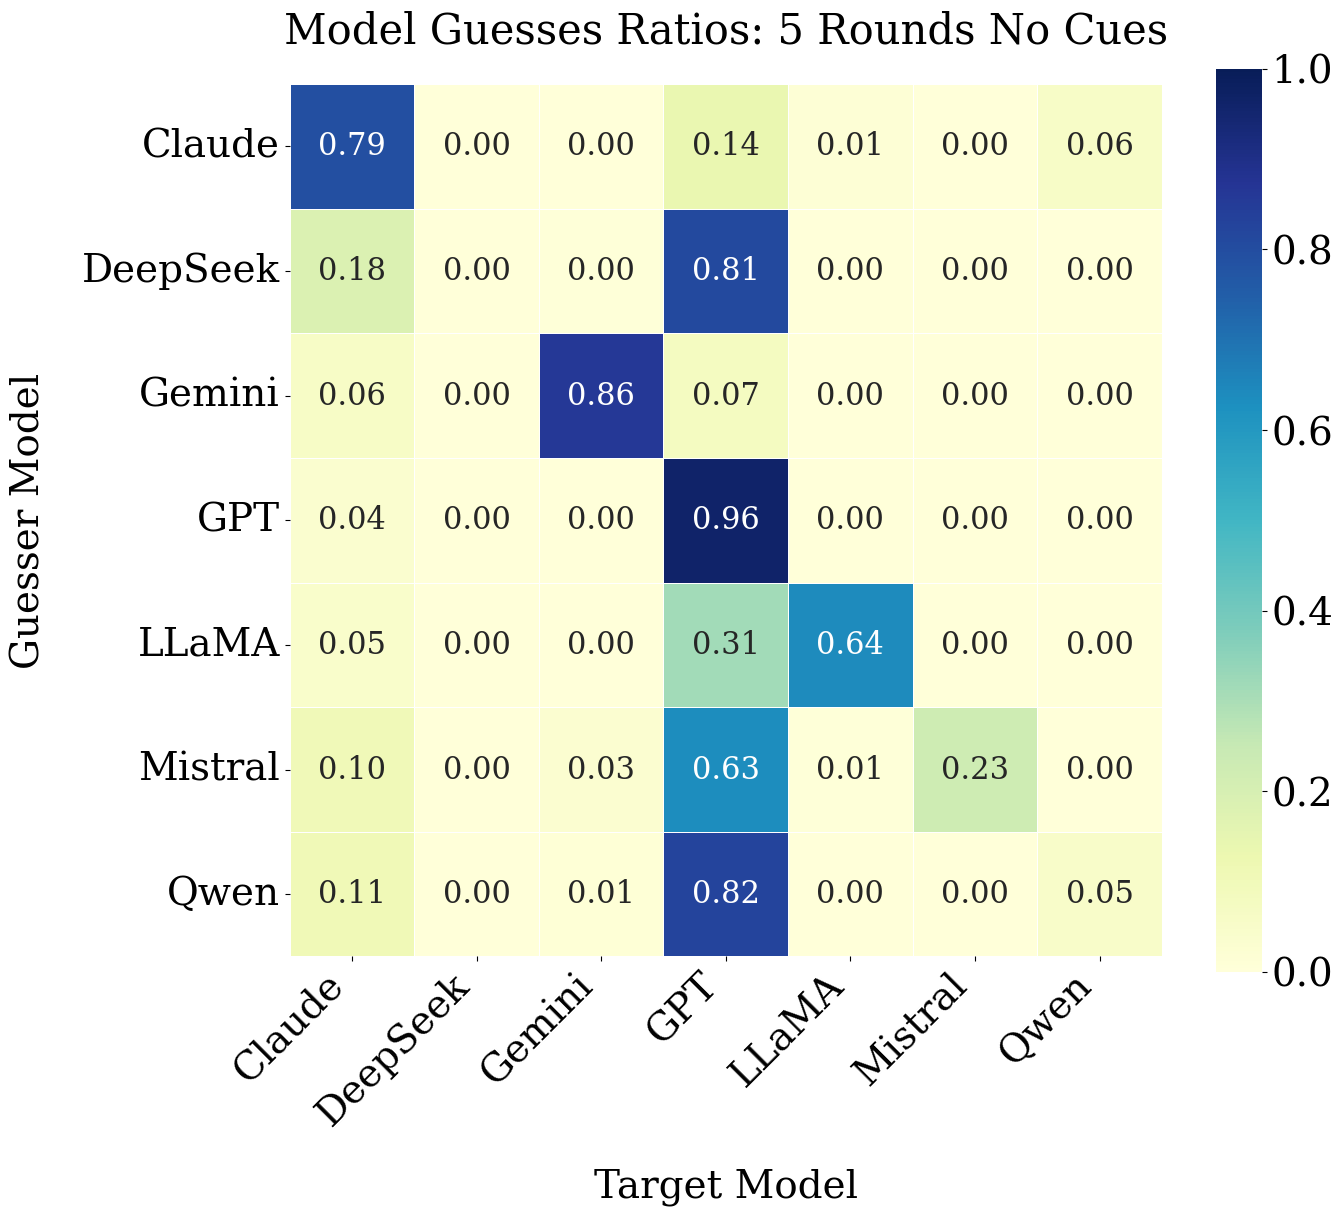

\begin{tabular}{lrrrrrrr}
\toprule
 & claude & deepseek & gemini & gpt & llama & mistral & qwen \\
\midrule
claude & 0.794145 & 0.001830 & 0.000000 & 0.135407 & 0.012809 & 0.000000 & 0.055810 \\
deepseek & 0.184080 & 0.000000 & 0.004146 & 0.810116 & 0.000000 & 0.000000 & 0.001658 \\
gemini & 0.059984 & 0.000000 & 0.862777 & 0.074774 & 0.000000 & 0.000000 & 0.002465 \\
gpt & 0.035088 & 0.000000 & 0.000000 & 0.961722 & 0.000000 & 0.000000 & 0.003190 \\
llama & 0.046341 & 0.000000 & 0.000813 & 0.314634 & 0.637398 & 0.000000 & 0.000813 \\
mistral & 0.102834 & 0.000000 & 0.027530 & 0.633198 & 0.005668 & 0.227530 & 0.003239 \\
qwen & 0.108243 & 0.000000 & 0.011657 & 0.824313 & 0.000833 & 0.001665 & 0.053289 \\
\bottomrule
\end{tabular}



In [8]:
show_plot(df_5_n_count, "count_n5", "Model Guesses Ratios: 5 Rounds No Cues", rangify=False, fmt=".2f")
print(df_5_n_count.to_latex())

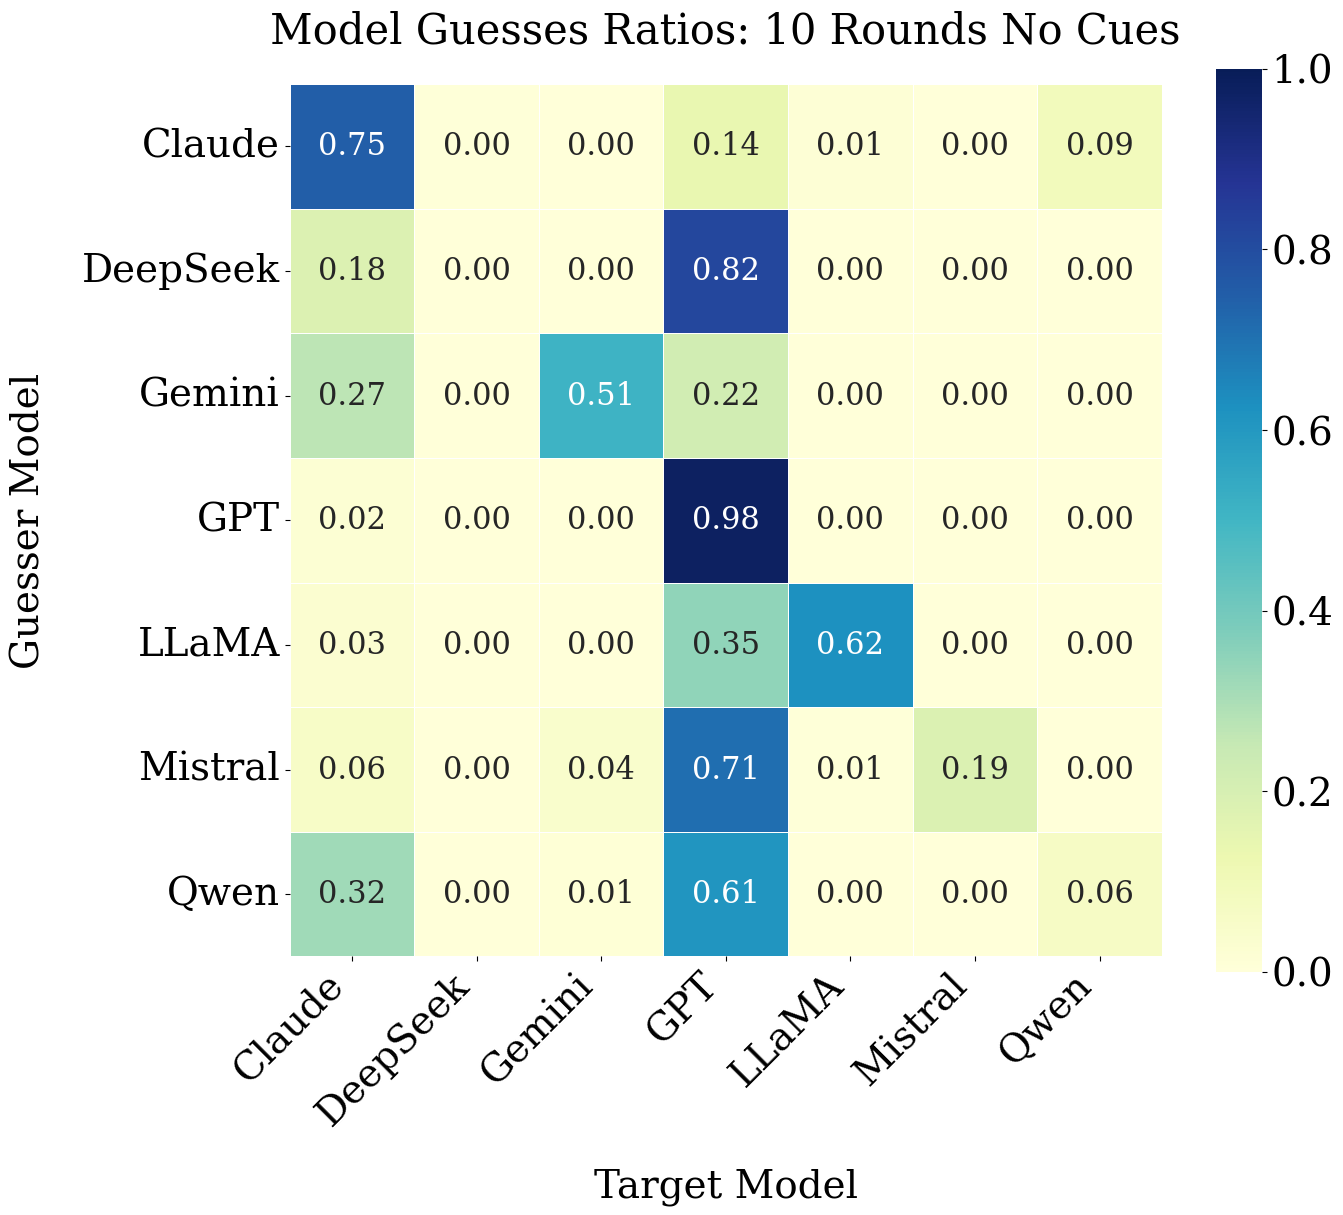

\begin{tabular}{lrrrrrrr}
\toprule
 & claude & deepseek & gemini & gpt & llama & mistral & qwen \\
\midrule
claude & 0.749526 & 0.004744 & 0.001898 & 0.137571 & 0.013283 & 0.001898 & 0.091082 \\
deepseek & 0.181208 & 0.000000 & 0.000000 & 0.818792 & 0.000000 & 0.000000 & 0.000000 \\
gemini & 0.266776 & 0.000000 & 0.511457 & 0.218494 & 0.000000 & 0.000000 & 0.003273 \\
gpt & 0.019560 & 0.000000 & 0.000000 & 0.977995 & 0.000000 & 0.000000 & 0.002445 \\
llama & 0.030353 & 0.000000 & 0.000000 & 0.347006 & 0.622642 & 0.000000 & 0.000000 \\
mistral & 0.055510 & 0.000000 & 0.039768 & 0.710853 & 0.007457 & 0.186413 & 0.000000 \\
qwen & 0.316681 & 0.000000 & 0.008467 & 0.610500 & 0.000000 & 0.000000 & 0.064352 \\
\bottomrule
\end{tabular}



In [9]:
show_plot(df_10_n_count, "count_n10", "Model Guesses Ratios: 10 Rounds No Cues", rangify=False, fmt=".2f")
print(df_10_n_count.to_latex())

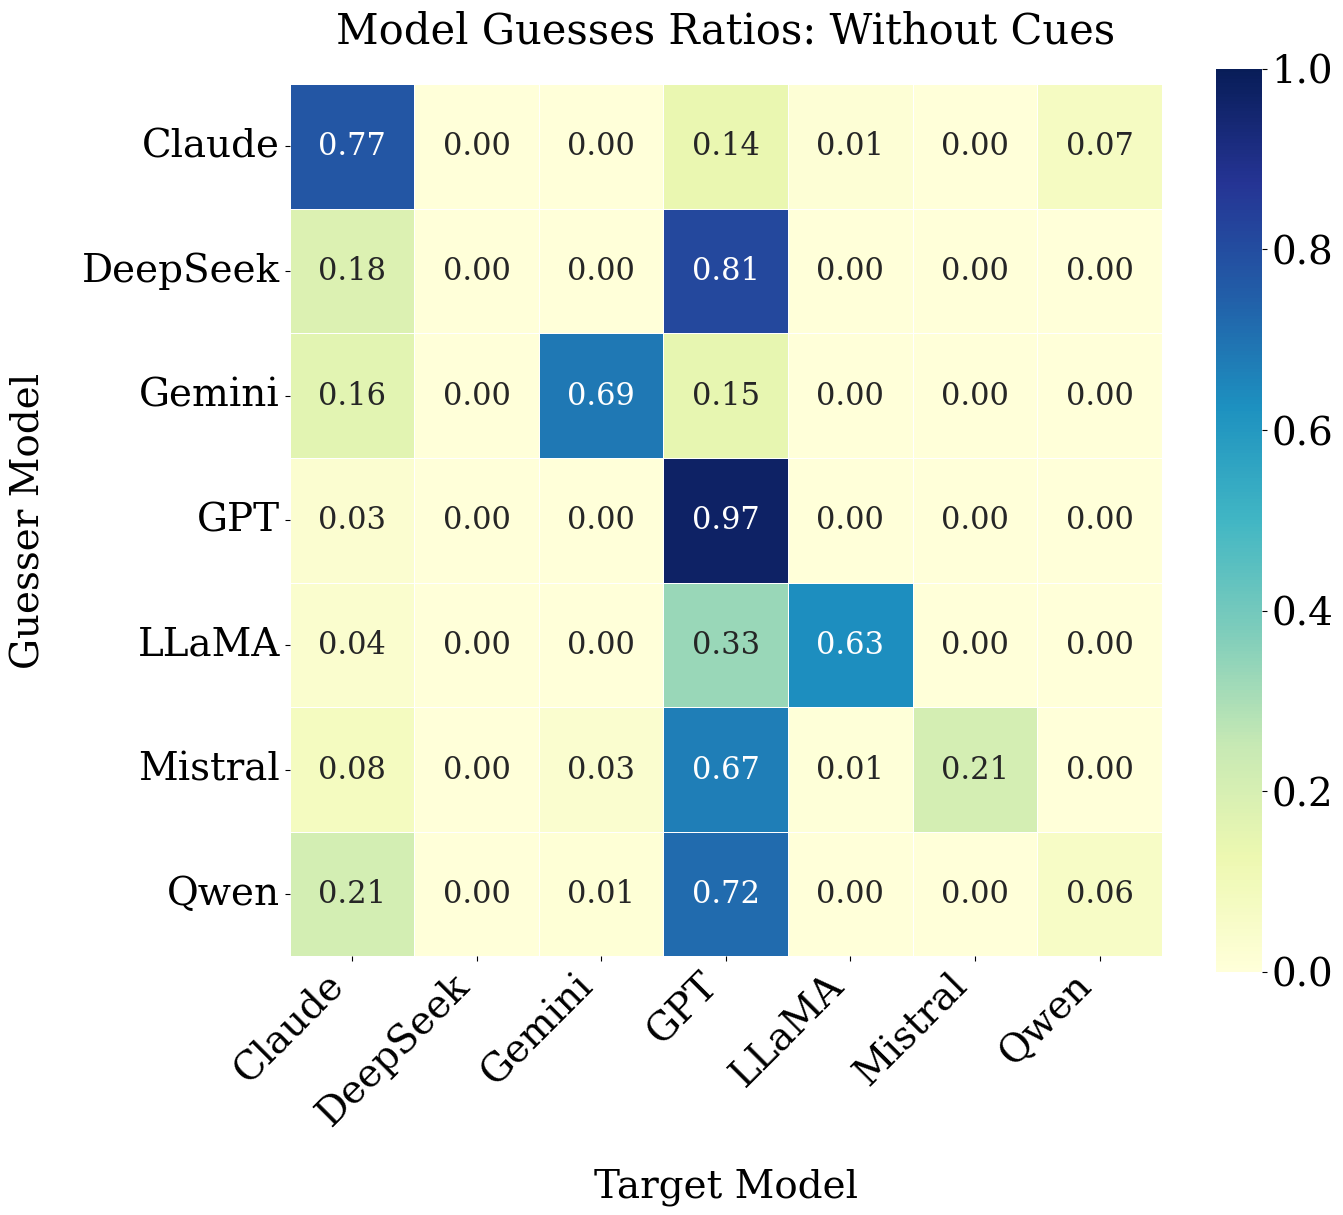

\begin{tabular}{lrrrrrrr}
\toprule
 & claude & deepseek & gemini & gpt & llama & mistral & qwen \\
\midrule
claude & 0.772240 & 0.003260 & 0.000932 & 0.136469 & 0.013041 & 0.000932 & 0.073125 \\
deepseek & 0.182652 & 0.000000 & 0.002085 & 0.814429 & 0.000000 & 0.000000 & 0.000834 \\
gemini & 0.163592 & 0.000000 & 0.686757 & 0.146781 & 0.000000 & 0.000000 & 0.002870 \\
gpt & 0.027408 & 0.000000 & 0.000000 & 0.969770 & 0.000000 & 0.000000 & 0.002821 \\
llama & 0.038383 & 0.000000 & 0.000408 & 0.330747 & 0.630053 & 0.000000 & 0.000408 \\
mistral & 0.079443 & 0.000000 & 0.033579 & 0.671581 & 0.006552 & 0.207207 & 0.001638 \\
qwen & 0.211587 & 0.000000 & 0.010076 & 0.718304 & 0.000420 & 0.000840 & 0.058774 \\
\bottomrule
\end{tabular}



In [10]:
show_plot(df_n_count, "count_n", "Model Guesses Ratios: Without Cues", rangify=False, fmt=".2f")
print(df_n_count.to_latex())

In [11]:
model_names = ["claude", "deepseek", "gemini", "gpt", "llama", "mistral", "qwen"]
pretty_names = {
    "gpt": "GPT",
    "llama": "LLaMA",
    "mistral": "Mistral",
    "claude": "Claude",
    "qwen": "Qwen",
    "gemini": "Gemini",
    "deepseek": "DeepSeek"
}

def transform_data_acc(data):
    correct_counts = {a: {b: 0 for b in model_names} for a in model_names}
    total_counts = {a: {b: 0 for b in model_names} for a in model_names}
    
    for entry in data:
        model_0 = entry["model_general_name_0"].lower()
        model_1 = entry["model_general_name_1"].lower()
        guess_0 = entry["agent_0_guess"].lower()
        guess_1 = entry["agent_1_guess"].lower()
    
        if model_0 in model_names and model_1 in model_names:
            total_counts[model_0][model_1] += 1
            if guess_0 == model_1:
                correct_counts[model_0][model_1] += 1

        if model_1 in model_names and model_0 in model_names:
            total_counts[model_1][model_0] += 1
            if guess_1 == model_0:
                correct_counts[model_1][model_0] += 1
    
    accuracy_matrix = {
        a: {
            b: (correct_counts[a][b] / total_counts[a][b]) if total_counts[a][b] > 0 else None
            for b in model_names
        }
        for a in model_names
    }
    
    df_accuracy = pd.DataFrame(accuracy_matrix).T

    return df_accuracy

df_5_c_acc = transform_data_acc(data_cues_5)
df_10_c_acc = transform_data_acc(data_cues_10)
df_5_n_acc = transform_data_acc(data_none_5)
df_10_n_acc = transform_data_acc(data_none_10)

df_c_acc = transform_data_acc(data_cues)
df_n_acc = transform_data_acc(data_none)
df_5_acc = transform_data_acc(data_5)
df_10_acc = transform_data_acc(data_10)

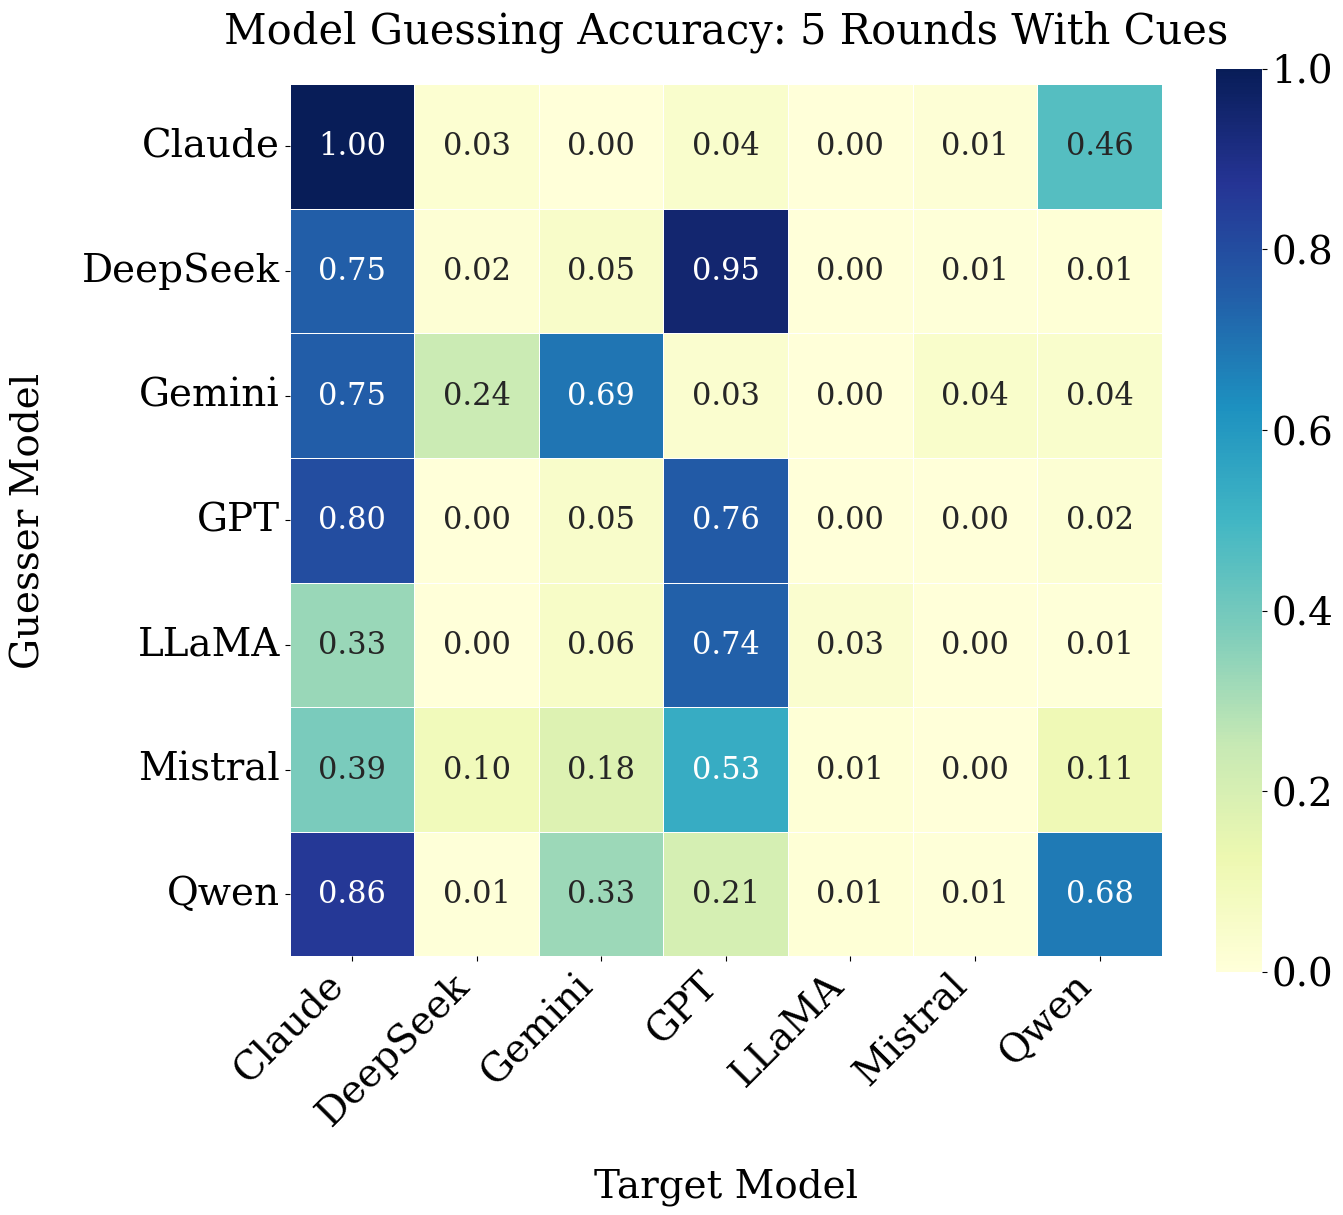

In [12]:
show_plot(df_5_c_acc, "acuracy_c5", "Model Guessing Accuracy: 5 Rounds With Cues")

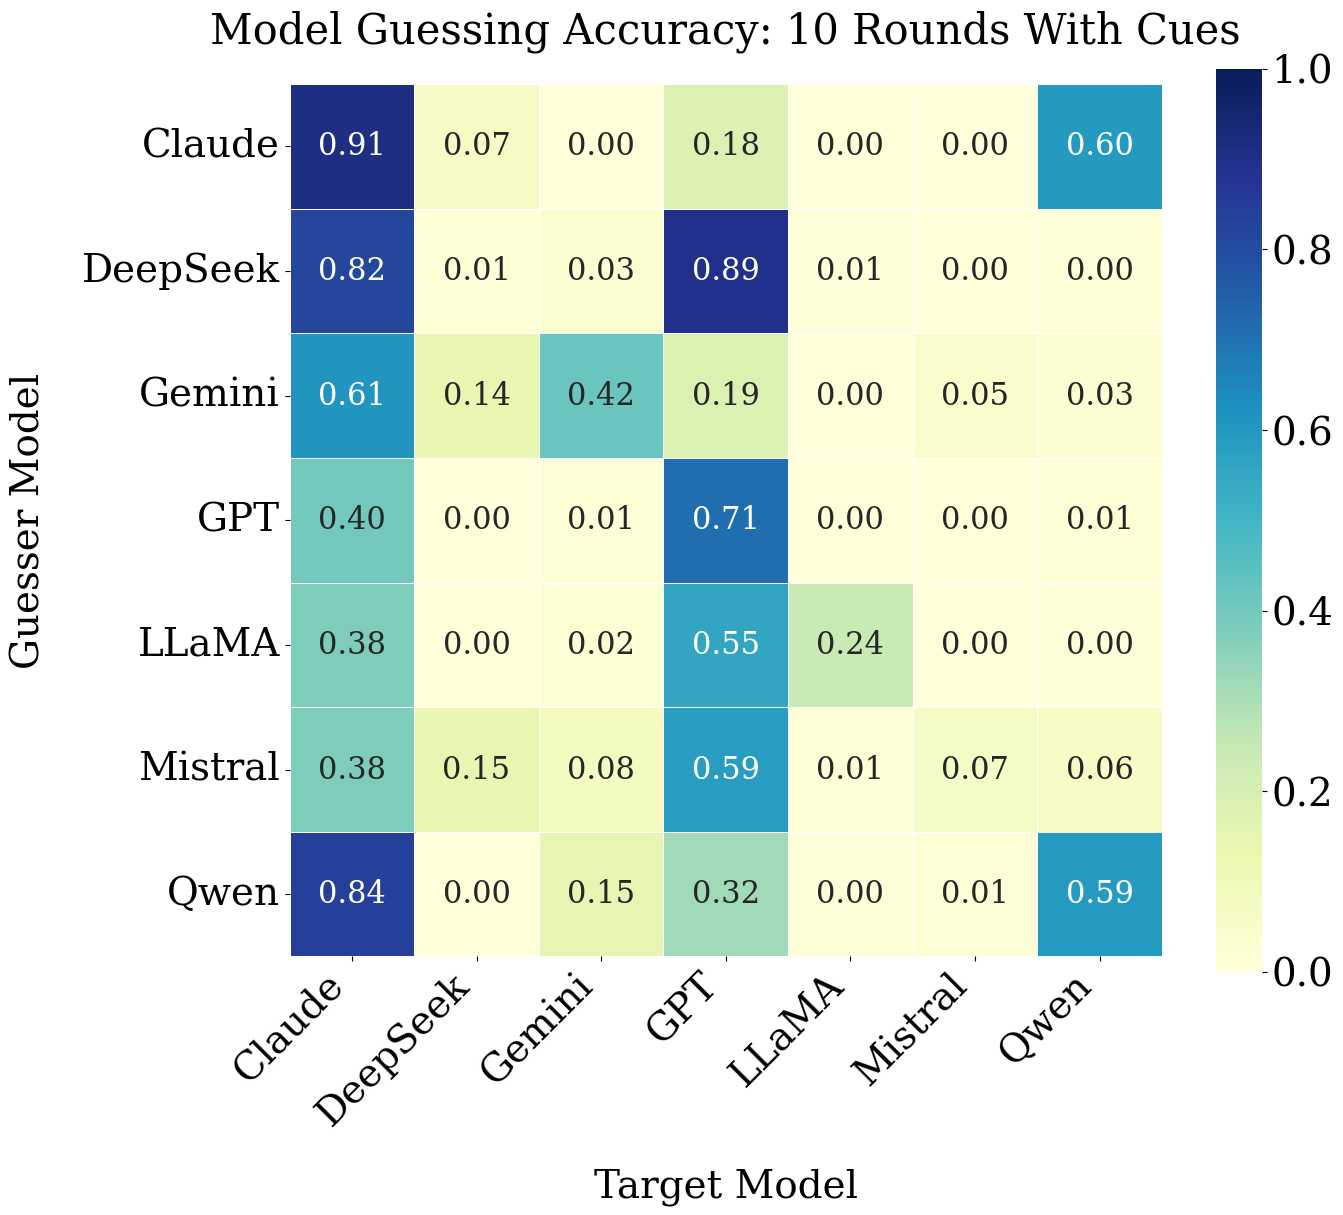

In [13]:
show_plot(df_10_c_acc, "accuracy_c10", "Model Guessing Accuracy: 10 Rounds With Cues")

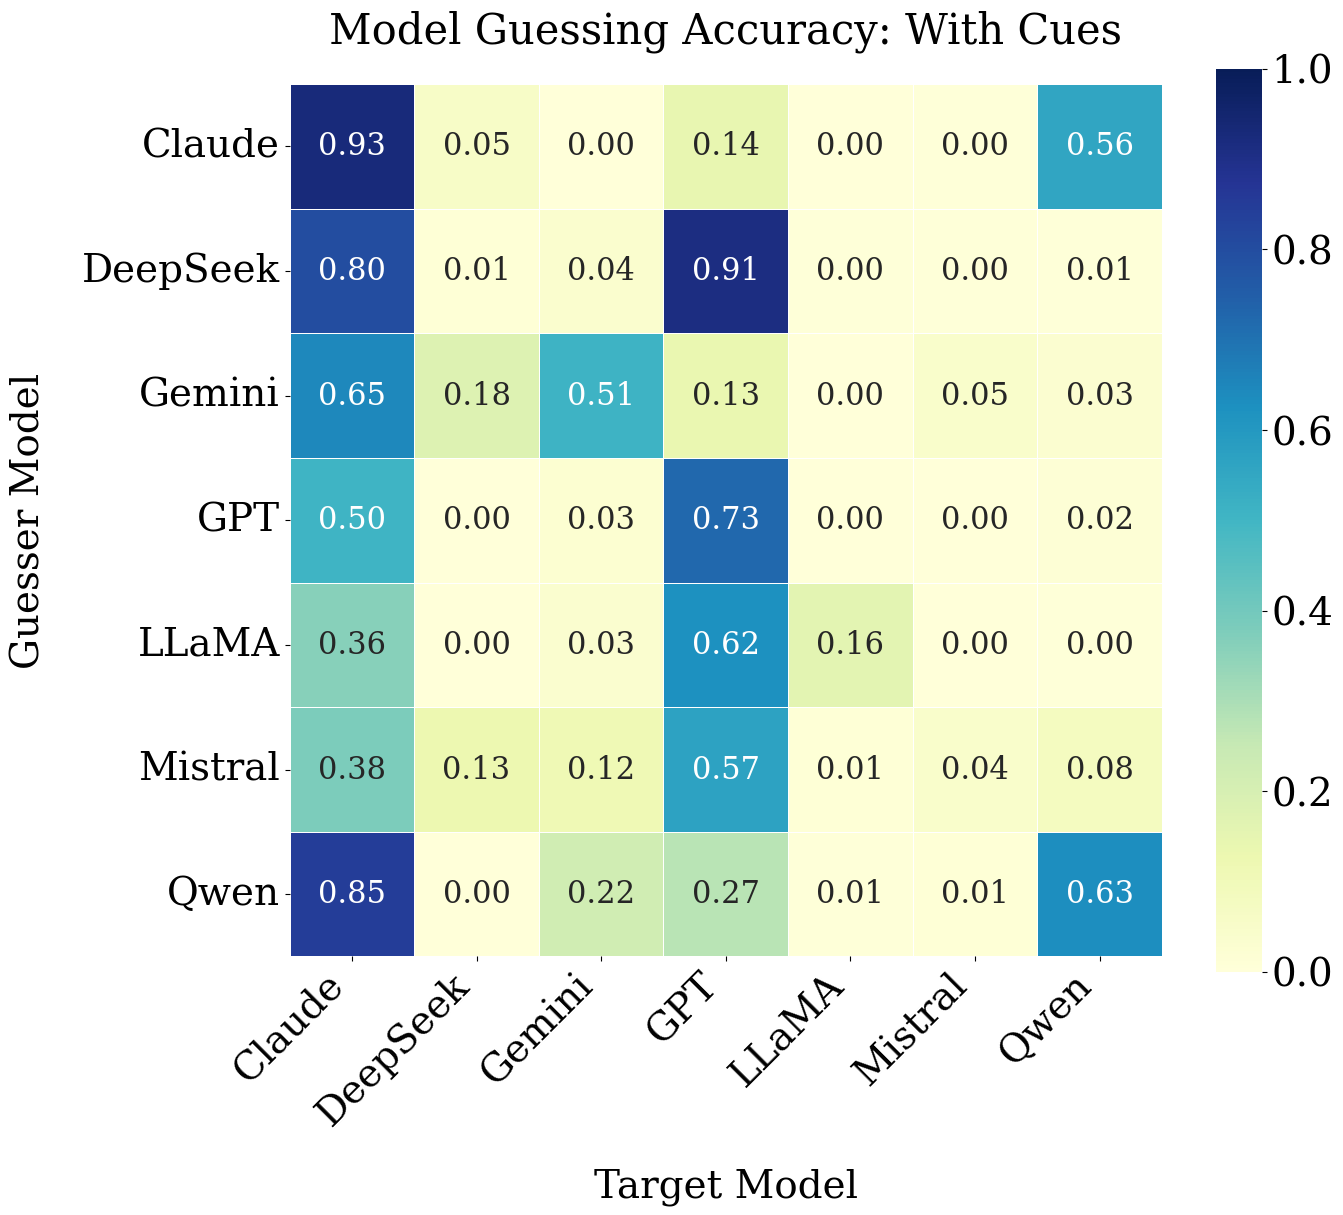

In [14]:
show_plot(df_c_acc, "accuracy_c", "Model Guessing Accuracy: With Cues")

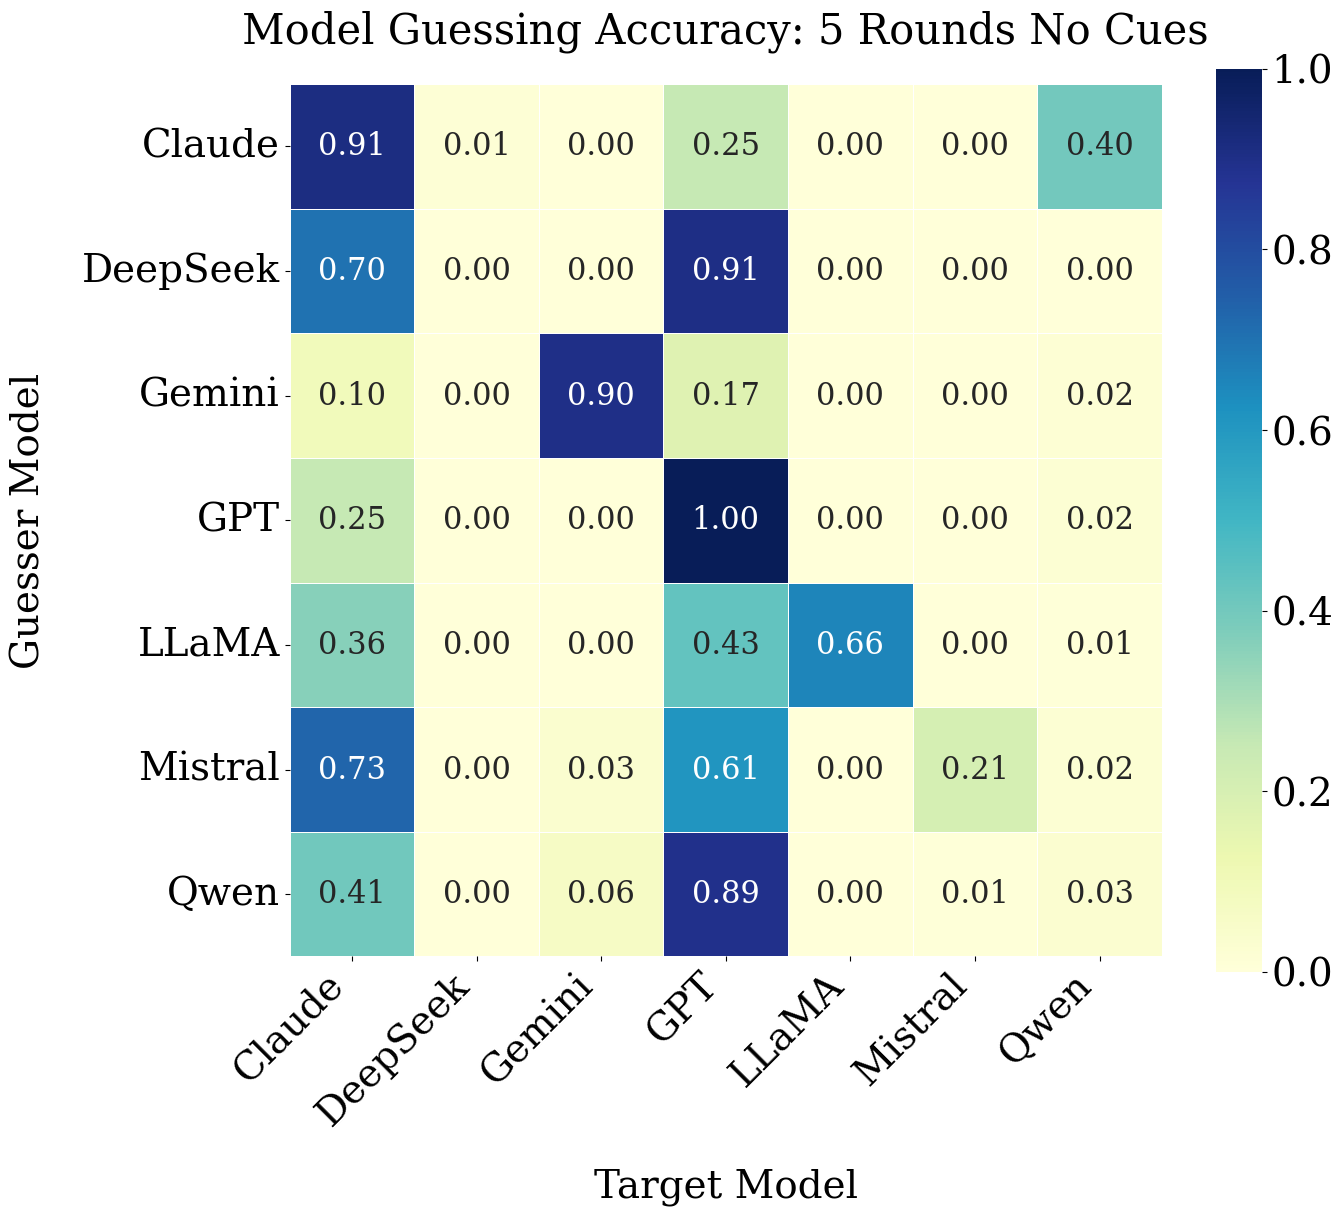

In [15]:
show_plot(df_5_n_acc, "accuracy_n5", "Model Guessing Accuracy: 5 Rounds No Cues")

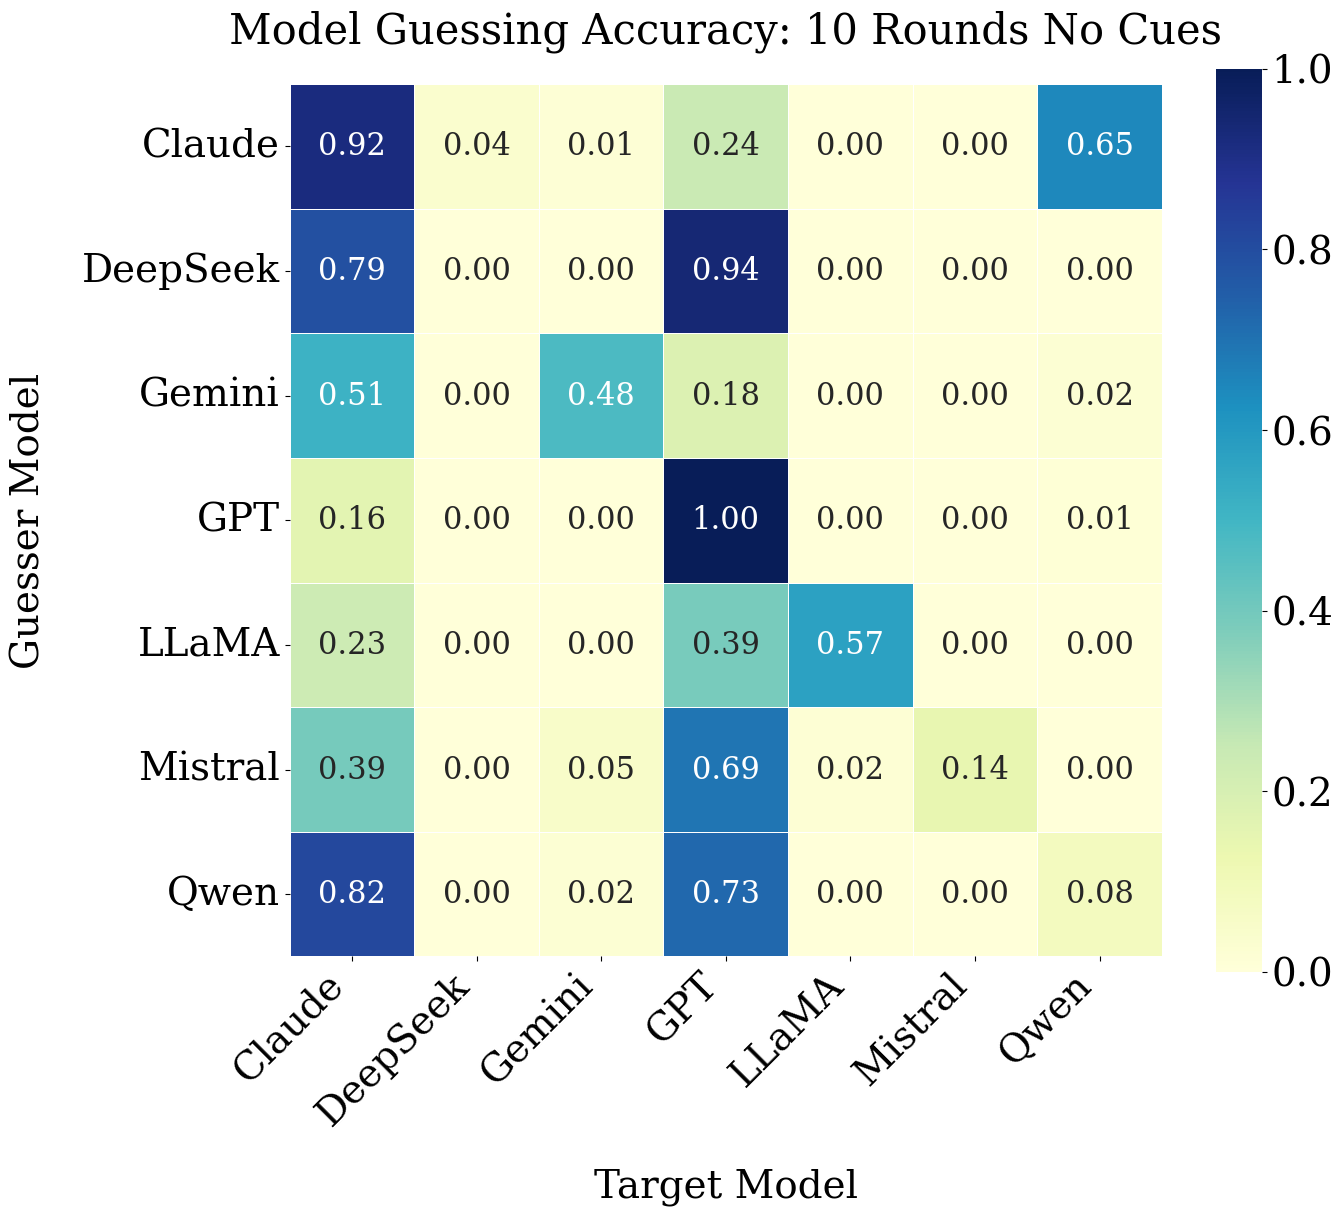

In [16]:
show_plot(df_10_n_acc, "accuracy_n10", "Model Guessing Accuracy: 10 Rounds No Cues")

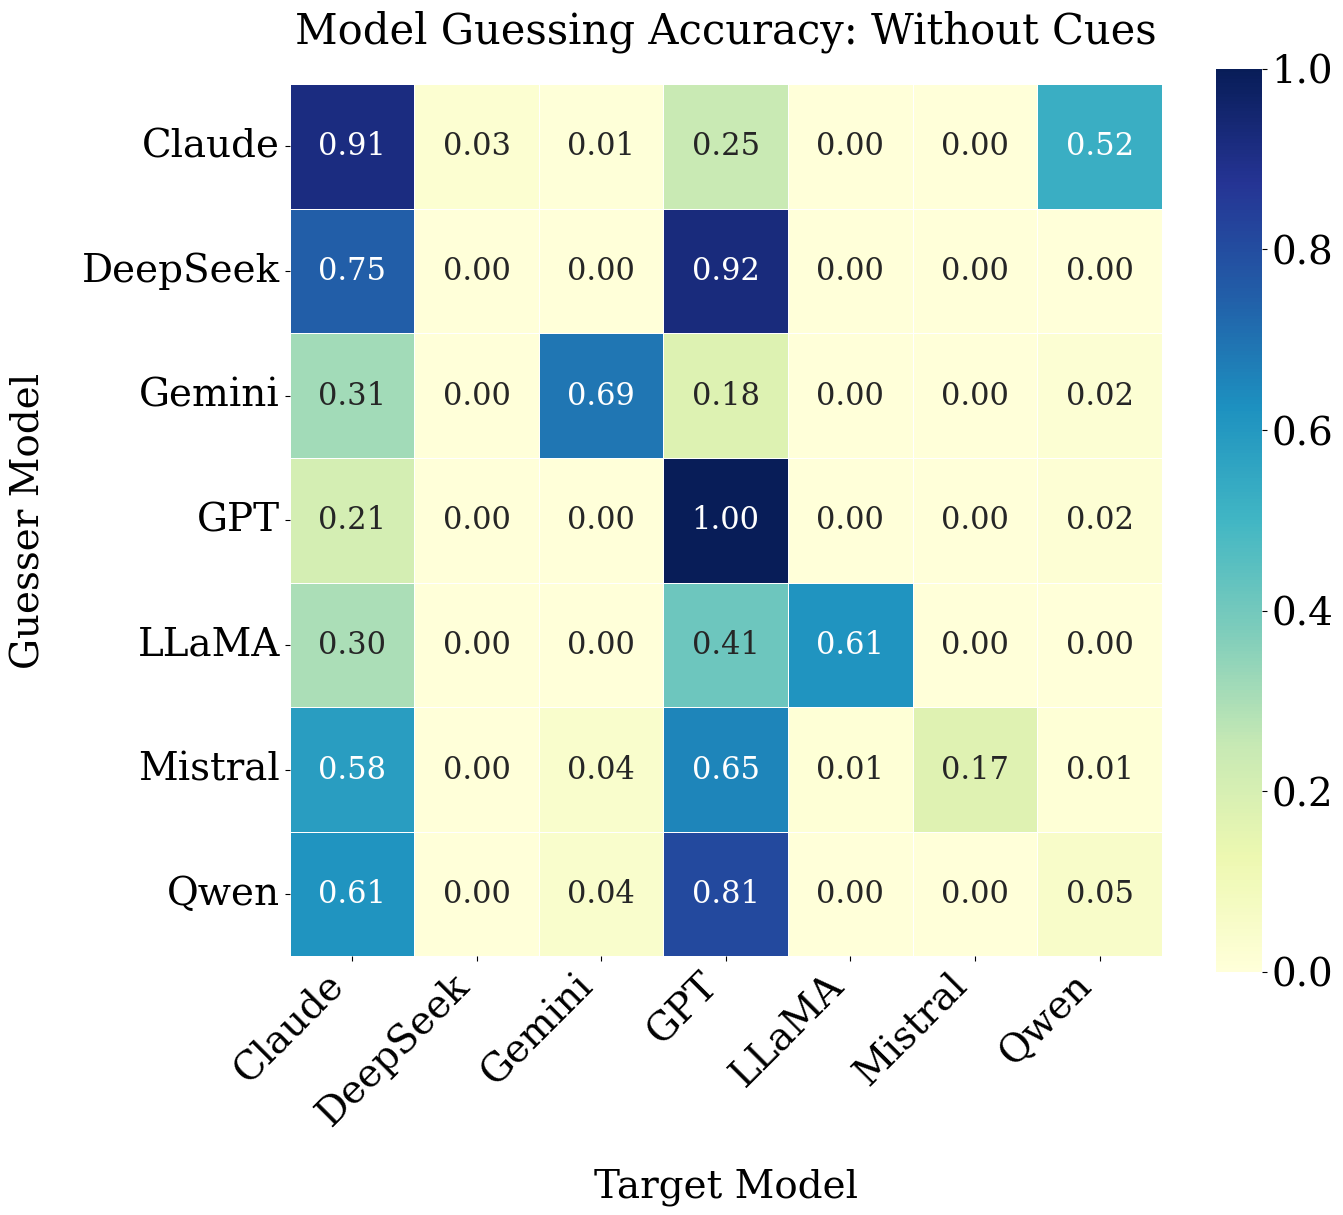

In [17]:
show_plot(df_n_acc, "accuracy_n", "Model Guessing Accuracy: Without Cues")

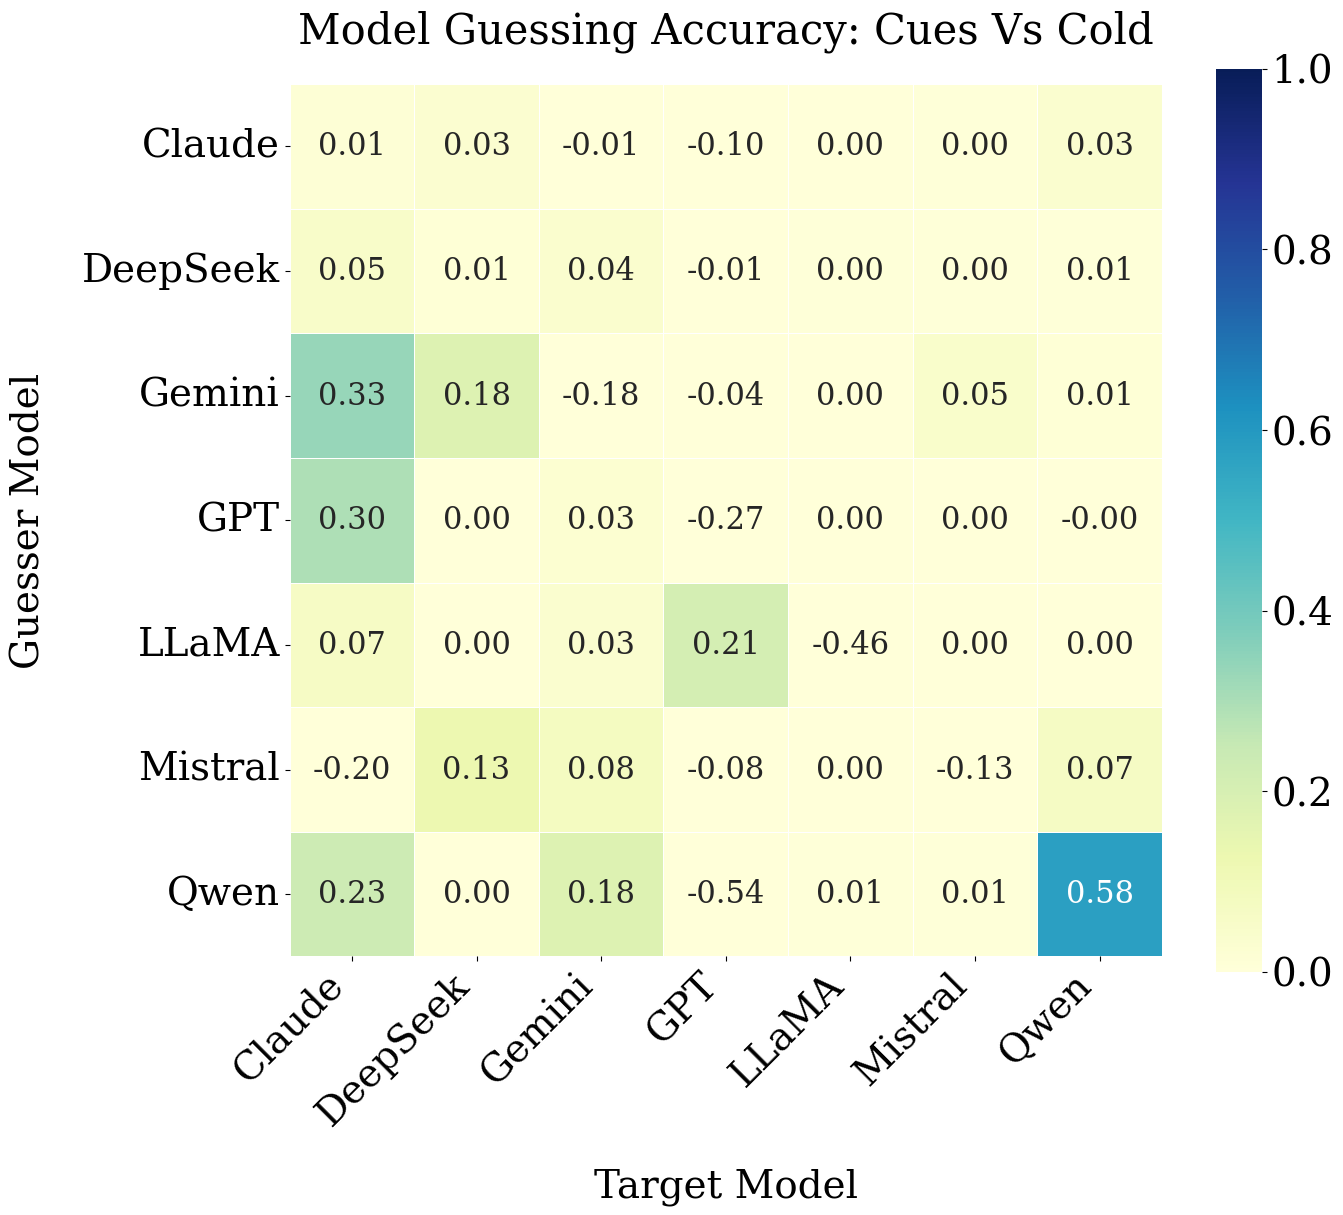

In [18]:
show_plot(df_c_acc - df_n_acc, "accuracy_cues_vs_none", "Model Guessing Accuracy: Cues Vs Cold", rangify=False)

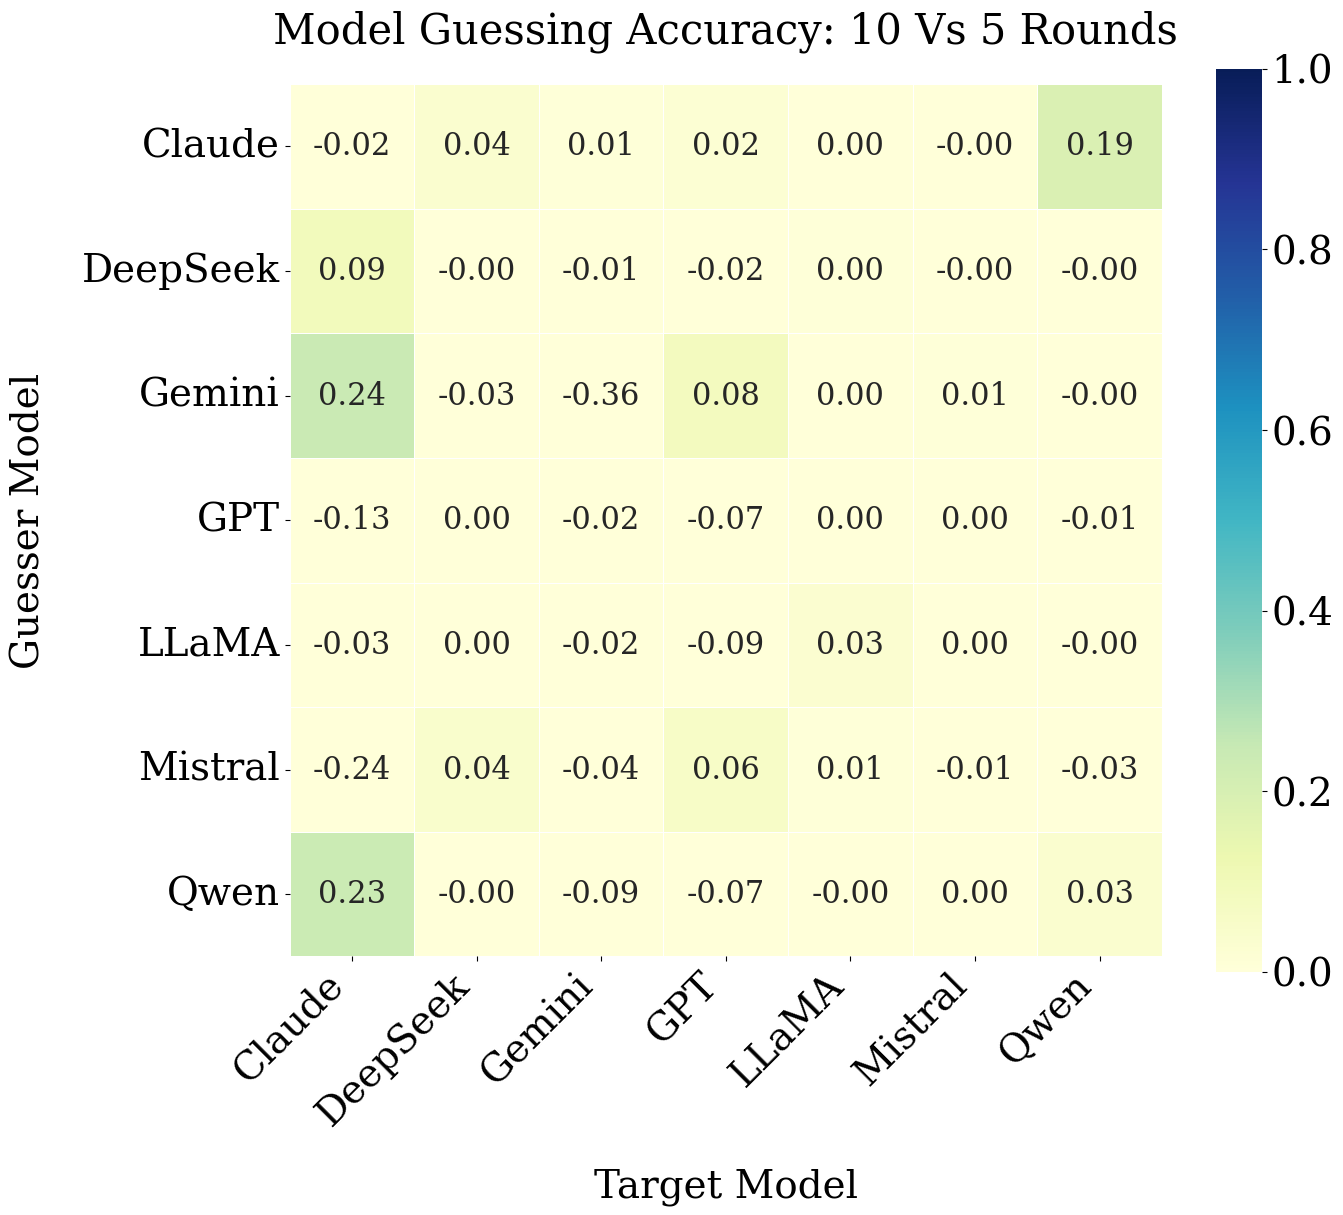

In [19]:
show_plot(df_10_acc - df_5_acc, "accuracy_10_vs_5", "Model Guessing Accuracy: 10 Vs 5 Rounds", rangify=False)